# Past Claims as a Feature

Single source of claims. We compare four models:
1. **Baseline** — trained on the N raw Gaussian features only
2. **+ count** — adds `past_claims` (cumulative claim count) as a feature
3. **+ frequency** — adds `past_claims / time` (claims per year so far) as a feature
4. **+ Bayesian freq** — adds a credibility-weighted frequency: `(past_claims + prior_weight × FREQ) / (time + prior_weight)`, starting at `FREQ` instead of 0

We evaluate overall and by contract-time buckets: [0,1], [1,2], [2,4], 4+.

## 0. Parameters

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import claimssimulator as csim
from claimssimulator.metrics import gini, calibration_quality_ratio as cqr, r2, rmse, mape

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ── Experiment parameters ─────────────────────────────────────
N_FEATURES       = 6          # number of Gaussian features
N_SAMPLES        = 10_000     # number of policies
CONTRACT_MEAN    = 5.0        # mean contract duration (years, Exponential)
CONTRACT_MAX     = 10.0       # cap on contract duration
FREQ             = 0.20       # base frequency
NOISE_RATIO      = 0.5        # fraction of log-risk variance from unobserved noise
                              # (0.0 = fully observable, 0.5 = half hidden)
SEED             = 42

## 1. Feature Specification & Data Generation

In [2]:
feature_spec = [
    csim.Feature(f'x{i}', csim.Normal(loc=0, scale=1))
    for i in range(N_FEATURES)
]

feature_spec.append(
    csim.Feature(
        'contract_duration_years',
        csim.Exponential(scale=CONTRACT_MEAN),
        csim.Transform(lambda x: np.clip(x, 0.1, CONTRACT_MAX)),
    )
)

feat_def = csim.FeatureDefinition(feature_spec)
df = feat_def.generate(n_samples=N_SAMPLES, random_seed=SEED)

print(f"Generated {len(df):,} policies  ·  {len(df.columns)} columns")
df.head()

Generated 10,000 policies  ·  7 columns


,x0,x1,x2,x3,x4,x5,contract_duration_years
0,0.304717,0.176277,-1.658201,-1.011428,-0.899768,0.769680,5.264864
1,-1.039984,0.899123,0.891207,-0.047397,-1.258172,-1.843905,1.573755
2,0.750451,-1.472271,-0.058032,-1.346366,0.332616,-0.239658,1.686059
3,0.940565,-0.285298,-0.599909,-0.715356,0.153343,-1.090636,5.190288
4,-1.951035,0.829153,-0.250818,-0.244191,-2.224559,2.863653,10.000000


## 2. Build Risk Direction & Claim Rate

In [3]:
rng = np.random.default_rng(SEED)

# Random unit vector for the observable signal
w = rng.standard_normal(N_FEATURES)
w = w / np.linalg.norm(w)

X = df[[f'x{i}' for i in range(N_FEATURES)]].values
signal = X @ w   # std ≈ 1 (unit vector dotted with iid N(0,1))

# Unobserved heterogeneity (hidden random effect per policy)
# NOISE_RATIO controls how much of log-risk variance is unobservable:
#   log_risk = sqrt(1 - NOISE_RATIO) * signal + sqrt(NOISE_RATIO) * noise
# so Var(log_risk) = 1, with fraction (1-NOISE_RATIO) from signal and NOISE_RATIO from noise.
noise = rng.standard_normal(N_SAMPLES)

df['risk_signal'] = np.sqrt(1 - NOISE_RATIO) * signal     # observable part
df['risk_noise']  = np.sqrt(NOISE_RATIO) * noise           # unobservable part
df['risk_factor'] = df['risk_signal'] + df['risk_noise']   # total log-risk

df['rate'] = FREQ * np.exp(df['risk_factor'].values)

print(f"NOISE_RATIO = {NOISE_RATIO}  →  {(1-NOISE_RATIO)*100:.0f}% of log-risk variance is observable")
print(f"Risk signal — std: {df['risk_signal'].std():.3f}")
print(f"Risk noise  — std: {df['risk_noise'].std():.3f}")
print(f"Risk factor — std: {df['risk_factor'].std():.3f}")
print(f"Rate        — mean: {df['rate'].mean():.4f},  median: {df['rate'].median():.4f}")

NOISE_RATIO = 0.5  →  50% of log-risk variance is observable
Risk signal — std: 0.705
Risk noise  — std: 0.711
Risk factor — std: 1.005
Rate        — mean: 0.3295,  median: 0.1985


## 3. Simulate Claims

In [4]:
import importlib, claimssimulator.simulation
importlib.reload(claimssimulator.simulation)
from claimssimulator.simulation import ClaimSource, MultiCauseClaimsSimulator

sources = [
    ClaimSource(
        name='source_1',
        generator='Poisson',
        param_columns={'rate': 'rate'},
    ),
]

mc_sim = MultiCauseClaimsSimulator(
    sources=sources,
    time_to_simulate='contract_duration_years',
    max_exposure=1.0,
    exposure_column='exposure',
    claim_counter='past_claims',
    renewal_mode='contract_end',
    random_seed=SEED,
)

claim_df = mc_sim.simulate(df)
claim_df = claim_df.rename(columns={'claim_source_1': 'claims'})

print(f"Contracts : {len(df):,}")
print(f"Rows      : {len(claim_df):,}  ({len(claim_df)/len(df):.2f}× expansion)")
print(f"Total claims: {claim_df['claims'].sum():,}  "
      f"rate: {claim_df['claims'].sum() / claim_df['exposure'].sum():.4f}")

Contracts : 10,000
Rows      : 62,039  (6.20× expansion)
Total claims: 14,298  rate: 0.3304


## 4. Prepare Features for Modelling

In [ ]:
# Compute cumulative time elapsed at the start of each row
claim_df = claim_df.sort_values(['contract_id', 'past_claims']).reset_index(drop=True)
claim_df['time_elapsed'] = claim_df.groupby('contract_id')['exposure'].cumsum() - claim_df['exposure']

# Contract year: integer year number at the start of the current exposure period
claim_df['contract_year'] = np.floor(claim_df['time_elapsed']).astype(int)

# past_claims is already available from the simulator
# Compute past frequency: past_claims / time_elapsed (0 for first row)
claim_df['past_frequency'] = np.where(
    claim_df['time_elapsed'] > 0,
    claim_df['past_claims'] / claim_df['time_elapsed'],
    0.0,
)

# Bayesian frequency: credibility-weighted estimate starting at the portfolio mean (FREQ)
# Formula: (past_claims + prior_weight * FREQ) / (time_elapsed + prior_weight)
# With prior_weight = 1/FREQ this means ~1 "prior claim" worth of information
PRIOR_WEIGHT = 1.0 / FREQ   # equivalent years of prior experience
claim_df['past_frequency_bayes'] = (
    (claim_df['past_claims'] + PRIOR_WEIGHT * FREQ)
    / (claim_df['time_elapsed'] + PRIOR_WEIGHT)
)

base_cols = [f'x{i}' for i in range(N_FEATURES)] + ['contract_year']

feature_cols_base  = base_cols
feature_cols_count = base_cols + ['past_claims']
feature_cols_freq  = base_cols + ['past_frequency']
feature_cols_bayes = base_cols + ['past_frequency_bayes']

print(f"time_elapsed range: [{claim_df['time_elapsed'].min():.2f}, {claim_df['time_elapsed'].max():.2f}]")
print(f"contract_year range: [{claim_df['contract_year'].min()}, {claim_df['contract_year'].max()}]")
print(f"past_frequency       — mean: {claim_df['past_frequency'].mean():.4f}, "
      f"max: {claim_df['past_frequency'].max():.4f}")
print(f"past_frequency_bayes — mean: {claim_df['past_frequency_bayes'].mean():.4f}, "
      f"max: {claim_df['past_frequency_bayes'].max():.4f}")
claim_df[['contract_id', 'time_elapsed', 'contract_year', 'past_claims', 'past_frequency', 'past_frequency_bayes', 'exposure', 'claims']].head(15)

time_elapsed range: [0.00, 10.00]
past_frequency       — mean: 1.1238, max: 16745.9237
past_frequency_bayes — mean: 0.3134, max: 4.4659


,contract_id,time_elapsed,past_claims,past_frequency,past_frequency_bayes,exposure,claims
0,0,0.000000,0,0.000000,0.200000,1.000000,0
1,0,1.000000,0,0.000000,0.166667,1.000000,0
2,0,2.000000,0,0.000000,0.142857,1.000000,0
3,0,3.000000,0,0.000000,0.125000,1.000000,0
4,0,4.000000,0,0.000000,0.111111,1.000000,0
5,0,5.000000,0,0.000000,0.100000,0.264864,0
6,1,0.000000,0,0.000000,0.200000,0.131081,1
7,1,0.131081,1,7.628871,0.389781,0.868919,0
8,1,1.000000,1,1.000000,0.333333,0.573755,0
9,2,0.000000,0,0.000000,0.200000,1.000000,0


## 5. Train EBM Models

In [6]:
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingRegressor

# Split at the policy level
unique_contracts = claim_df['contract_id'].unique()
contracts_train, contracts_test = train_test_split(unique_contracts, test_size=0.25, random_state=SEED)

train = claim_df[claim_df['contract_id'].isin(contracts_train)].copy()
test  = claim_df[claim_df['contract_id'].isin(contracts_test)].copy()

w_train = train['exposure']
w_test  = test['exposure']
y_train = train['claims'] / w_train
y_test  = test['claims'] / w_test

print(f"Train: {len(train):,} rows  ({train['claims'].sum():,.0f} claims)")
print(f"Test : {len(test):,} rows   ({test['claims'].sum():,.0f} claims)")

EBM_PARAMS = dict(max_bins=64, max_rounds=300, learning_rate=0.05,
                  objective='poisson_deviance', random_state=SEED)

# ── Model 1: base features only ─────────────────────────────
ebm_base = ExplainableBoostingRegressor(**EBM_PARAMS)
ebm_base.fit(train[feature_cols_base], y_train, sample_weight=w_train)
print("ebm_base       ✓")

# ── Model 2: base + past_claims ──────────────────────────────
ebm_count = ExplainableBoostingRegressor(**EBM_PARAMS)
ebm_count.fit(train[feature_cols_count], y_train, sample_weight=w_train)
print("ebm_count      ✓")

# ── Model 3: base + past_frequency ───────────────────────────
ebm_freq = ExplainableBoostingRegressor(**EBM_PARAMS)
ebm_freq.fit(train[feature_cols_freq], y_train, sample_weight=w_train)
print("ebm_freq       ✓")

# ── Model 4: base + Bayesian frequency ───────────────────────
ebm_bayes = ExplainableBoostingRegressor(**EBM_PARAMS)
ebm_bayes.fit(train[feature_cols_bayes], y_train, sample_weight=w_train)
print("ebm_bayes      ✓")

Train: 46,476 rows  (10,642 claims)
Test : 15,563 rows   (3,656 claims)
ebm_base       ✓
ebm_base       ✓
ebm_count      ✓
ebm_count      ✓
ebm_freq       ✓
ebm_freq       ✓
ebm_bayes      ✓
ebm_bayes      ✓


## 6. Evaluation — Overall & by Time Bucket

We compute Gini and CQR on the full test set and on subsets filtered by `time_elapsed`.

In [7]:
# Predictions
test['pred_base']  = ebm_base.predict(test[feature_cols_base])
test['pred_count'] = ebm_count.predict(test[feature_cols_count])
test['pred_freq']  = ebm_freq.predict(test[feature_cols_freq])
test['pred_bayes'] = ebm_bayes.predict(test[feature_cols_bayes])

# Time buckets: [0,1), [1,2), [2,3), [3,4), [4,5), [5,6), 6+
def time_bucket(t):
    for i in range(6):
        if t < i + 1:
            return f'[{i}, {i+1})'
    return '6+'

test['time_bucket'] = test['time_elapsed'].apply(time_bucket)

print("Test set time-bucket distribution:")
print(test.groupby('time_bucket').agg(
    rows=('claims', 'count'),
    claims=('claims', 'sum'),
    exposure=('exposure', 'sum'),
).assign(rate=lambda d: d['claims'] / d['exposure']))
print()

Test set time-bucket distribution:
             rows  claims     exposure      rate
time_bucket                                     
6+           2939     690  2027.520341  0.340317
[0, 1)       3342     841  2312.583726  0.363663
[1, 2)       2665     627  1831.588469  0.342326
[2, 3)       2113     443  1506.959111  0.293969
[3, 4)       1836     461  1264.954406  0.364440
[4, 5)       1444     313  1018.599306  0.307285
[5, 6)       1224     281   841.136211  0.334072



In [8]:
def evaluate_subset(subset, label=''):
    """Compute Gini, CQR, R², RMSE and MAPE for the four models on a subset.
    Gini/CQR compare predictions vs observed claims.
    R²/RMSE/MAPE compare predictions vs the true underlying rate (noise included).
    """
    w      = subset['exposure'].values
    y      = subset['claims'].values
    y_rate = subset['rate'].values   # true rate = FREQ * exp(risk_factor), noise included
    results = {}
    for model_name, pred_col in [('base', 'pred_base'),
                                  ('+ count', 'pred_count'),
                                  ('+ frequency', 'pred_freq'),
                                  ('+ Bayes freq', 'pred_bayes')]:
        p = subset[pred_col].values
        results[model_name] = {
            'Gini': gini(y, p, w),
            'CQR':  cqr(y, p, w, n_bins=20, method='mse', norm='sqrt'),
            'R²':   r2(y_rate, p, w),
            'RMSE': rmse(y_rate, p, w),
            'MAPE': mape(y_rate, p, w),
        }
    return pd.DataFrame(results).T

buckets = [f'[{i}, {i+1})' for i in range(6)] + ['6+']

# ── Overall ──────────────────────────────────────────────────
print("=== Overall ===")
display(evaluate_subset(test, 'Overall'))

# ── By time bucket ───────────────────────────────────────────
for bucket in buckets:
    subset = test[test['time_bucket'] == bucket]
    if len(subset) < 50:
        continue
    print(f"\n=== Time bucket: {bucket}  ({len(subset):,} rows, {subset['claims'].sum():.0f} claims) ===")
    display(evaluate_subset(subset, bucket))

=== Overall ===


,Gini,CQR,R²,RMSE,MAPE
base,0.364241,0.267119,0.310085,0.378034,0.951750
+ count,0.410608,0.296679,0.495088,0.323400,0.802775
+ frequency,0.417979,0.308962,0.542002,0.308010,0.784940
+ Bayes freq,0.430803,0.331539,0.661784,0.264685,0.739383



=== Time bucket: [0, 1)  (3,342 rows, 841 claims) ===


,Gini,CQR,R²,RMSE,MAPE
base,0.358026,0.238942,0.308631,0.359327,0.937462
+ count,0.379973,0.236984,0.340264,0.351010,0.742655
+ frequency,0.386267,0.243336,0.360708,0.345529,0.811109
+ Bayes freq,0.380642,0.230710,0.420441,0.328991,0.875978



=== Time bucket: [1, 2)  (2,665 rows, 627 claims) ===


...

,Gini,CQR,R²,RMSE,MAPE
base,0.383804,0.258936,0.324363,0.386738,0.963898
+ count,0.458924,0.284875,0.594961,0.299439,0.819972
+ frequency,0.460266,0.296949,0.630009,0.286191,0.759231
+ Bayes freq,0.473721,0.324134,0.751304,0.234636,0.701132



=== Time bucket: [5, 6)  (1,224 rows, 281 claims) ===


,Gini,CQR,R²,RMSE,MAPE
base,0.341616,0.242624,0.285011,0.398870,0.965893
+ count,0.400303,0.269302,0.561356,0.312419,0.847652
+ frequency,0.387261,0.269981,0.581636,0.305111,0.753828
+ Bayes freq,0.406355,0.303919,0.745016,0.238198,0.690688



=== Time bucket: 6+  (2,939 rows, 690 claims) ===


,Gini,CQR,R²,RMSE,MAPE
base,0.383971,0.274060,0.288626,0.415408,0.951035
+ count,0.469046,0.310104,0.493703,0.350452,0.908840
+ frequency,0.461386,0.328305,0.619607,0.303768,0.711598
+ Bayes freq,0.483242,0.372407,0.785460,0.228129,0.606849


## 7. Visualisation — Gini by Time Bucket

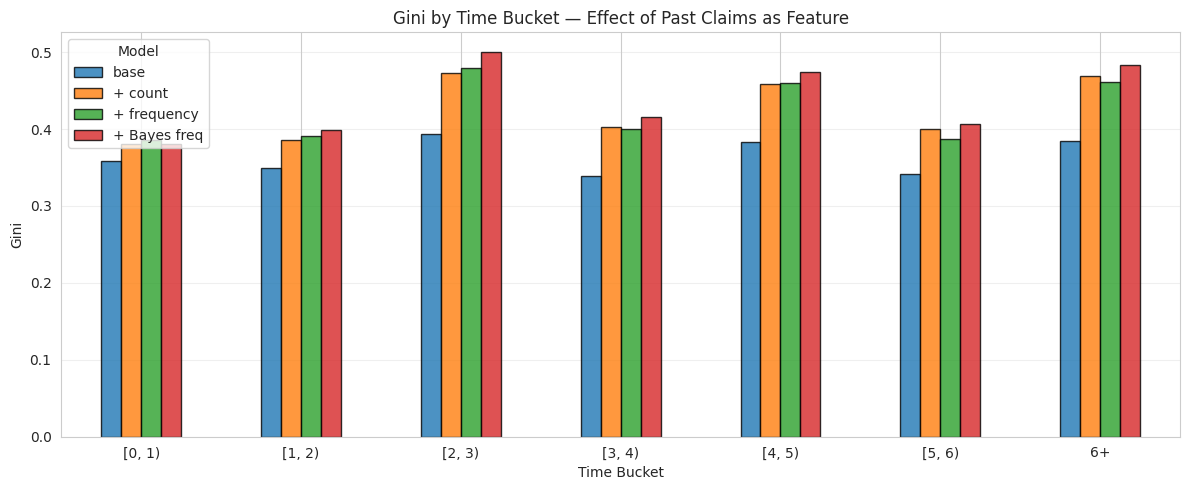

In [9]:
buckets = [f'[{i}, {i+1})' for i in range(6)] + ['6+']
gini_results = {}

for bucket in buckets:
    subset = test[test['time_bucket'] == bucket]
    if len(subset) < 50:
        continue
    w = subset['exposure'].values
    y = subset['claims'].values
    gini_results[bucket] = {
        'base':        gini(y, subset['pred_base'].values, w),
        '+ count':     gini(y, subset['pred_count'].values, w),
        '+ frequency': gini(y, subset['pred_freq'].values, w),
        '+ Bayes freq': gini(y, subset['pred_bayes'].values, w),
    }

gini_df = pd.DataFrame(gini_results).T

fig, ax = plt.subplots(figsize=(12, 5))
gini_df.plot(kind='bar', ax=ax, edgecolor='k', alpha=0.8)
ax.set_xlabel('Time Bucket')
ax.set_ylabel('Gini')
ax.set_title('Gini by Time Bucket — Effect of Past Claims as Feature')
ax.legend(title='Model')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

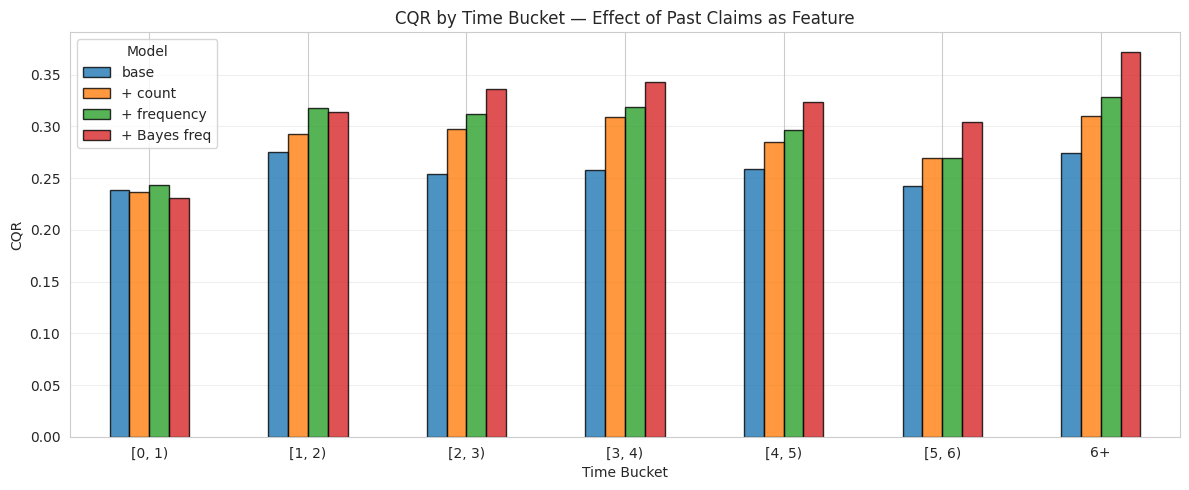

In [10]:
cqr_results = {}

for bucket in buckets:
    subset = test[test['time_bucket'] == bucket]
    if len(subset) < 50:
        continue
    w_b = subset['exposure'].values
    y_b = subset['claims'].values
    cqr_results[bucket] = {
        'base':         cqr(y_b, subset['pred_base'].values,  w_b, n_bins=20, method='mse', norm='sqrt'),
        '+ count':      cqr(y_b, subset['pred_count'].values, w_b, n_bins=20, method='mse', norm='sqrt'),
        '+ frequency':  cqr(y_b, subset['pred_freq'].values,  w_b, n_bins=20, method='mse', norm='sqrt'),
        '+ Bayes freq': cqr(y_b, subset['pred_bayes'].values, w_b, n_bins=20, method='mse', norm='sqrt'),
    }

cqr_df = pd.DataFrame(cqr_results).T

fig, ax = plt.subplots(figsize=(12, 5))
cqr_df.plot(kind='bar', ax=ax, edgecolor='k', alpha=0.8)
ax.set_xlabel('Time Bucket')
ax.set_ylabel('CQR')
ax.set_title('CQR by Time Bucket — Effect of Past Claims as Feature')
ax.legend(title='Model')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

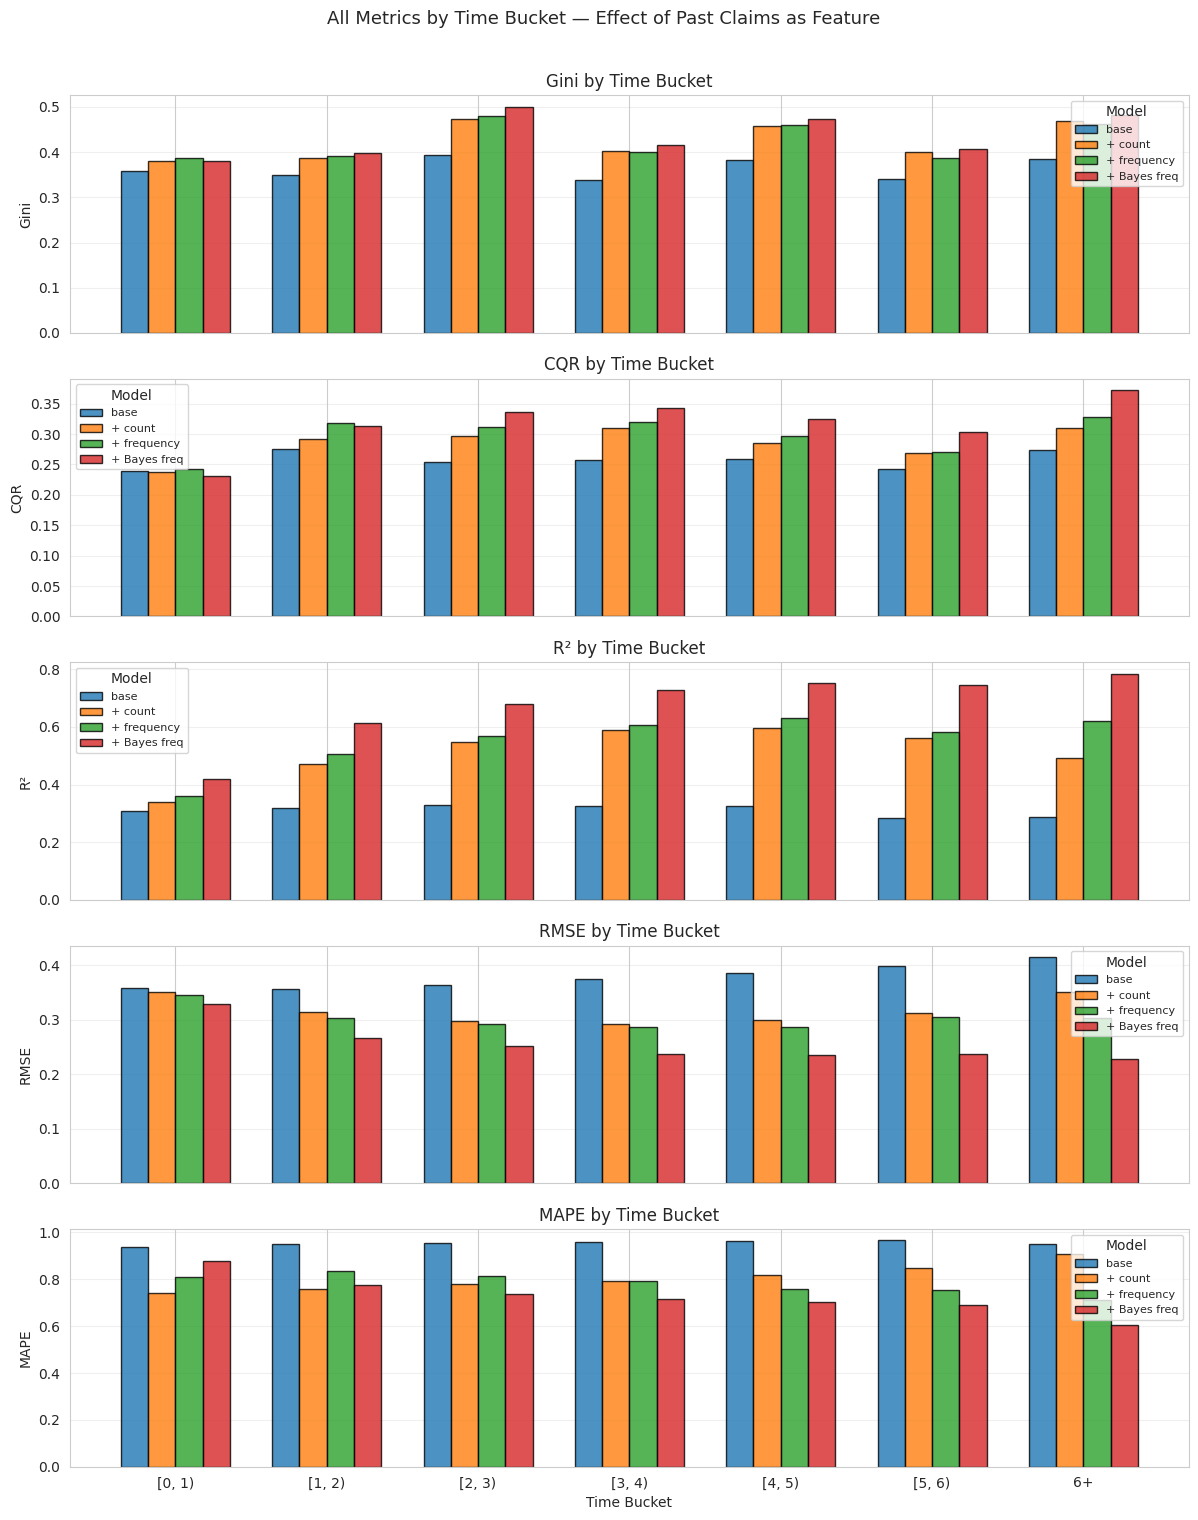

In [11]:
metrics_by_bucket = {}

for bucket in buckets:
    subset = test[test['time_bucket'] == bucket]
    if len(subset) < 50:
        continue
    w_b    = subset['exposure'].values
    y_b    = subset['claims'].values
    r_b    = subset['rate'].values
    row = {}
    for model_name, pred_col in [('base', 'pred_base'),
                                   ('+ count', 'pred_count'),
                                   ('+ frequency', 'pred_freq'),
                                   ('+ Bayes freq', 'pred_bayes')]:
        p = subset[pred_col].values
        row[model_name] = {
            'Gini': gini(y_b, p, w_b),
            'CQR':  cqr(y_b, p, w_b, n_bins=20, method='mse', norm='sqrt'),
            'R²':   r2(r_b, p, w_b),
            'RMSE': rmse(r_b, p, w_b),
            'MAPE': mape(r_b, p, w_b),
        }
    metrics_by_bucket[bucket] = row

metric_names = ['Gini', 'CQR', 'R²', 'RMSE', 'MAPE']
n_metrics    = len(metric_names)
valid_buckets = list(metrics_by_bucket.keys())
models        = ['base', '+ count', '+ frequency', '+ Bayes freq']

fig, axes = plt.subplots(n_metrics, 1, figsize=(12, 3 * n_metrics), sharex=True)

x     = np.arange(len(valid_buckets))
width = 0.18
offsets = np.linspace(-(len(models) - 1) / 2, (len(models) - 1) / 2, len(models)) * width

for ax, metric in zip(axes, metric_names):
    for offset, model in zip(offsets, models):
        vals = [metrics_by_bucket[b][model][metric] for b in valid_buckets]
        ax.bar(x + offset, vals, width=width, label=model, edgecolor='k', alpha=0.8)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Time Bucket')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(title='Model', fontsize=8)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(valid_buckets, rotation=0)
axes[-1].set_xlabel('Time Bucket')

fig.suptitle('All Metrics by Time Bucket — Effect of Past Claims as Feature', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()